**** LSQ METRICS ****
Mean Error LSQ: 0.426
Mean Absolute Error LSQ: 5.321
Maximum Error LSQ: 50.495
Minimum Error LSQ: 0.016

**** MLP METRICS ****
Mean Error MLP: 1.232
Mean Absolute Error MLP: 5.359
Maximum Error MLP: 50.801
Minimum Error MLP: 0.005


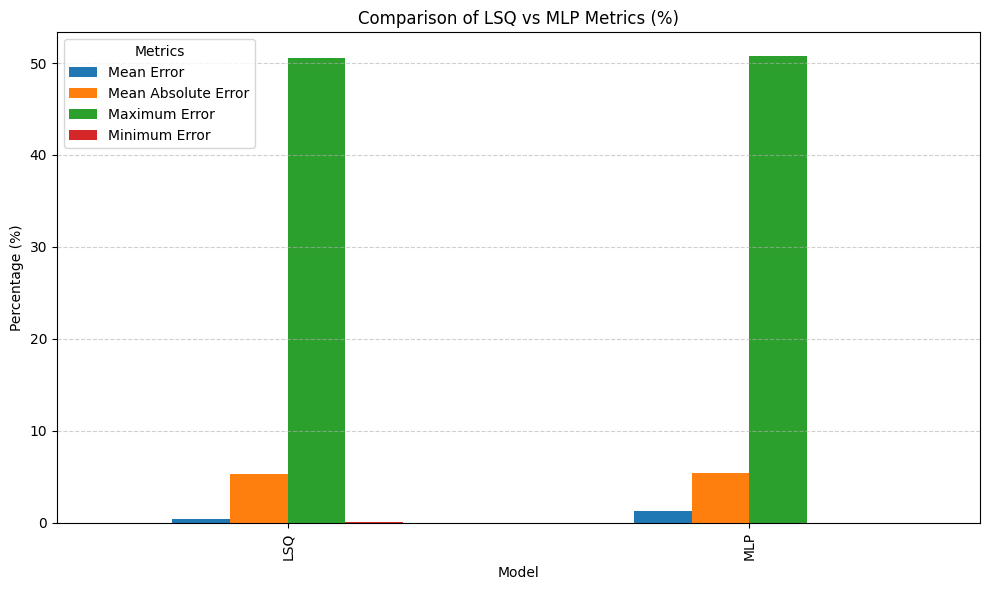

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("./results.xlsx")
df.pop('Unnamed: 14')
df.pop('Unnamed: 15')
df.pop('Unnamed: 16')
df.pop('Unnamed: 17')

# Delete rows where Comment column contains 'outlier' or 'invalid'
df = df[~df['Comment'].str.lower().isin(['outlier', 'invalid'])]

# LSQ  metrics
mean_error_lsq = df['Mean Error LSQ ( %):'].mean() * 100
mae_lsq = df['Mean Absolute Error LSQ ( %):'].mean() * 100
max_error_lsq = df['Mean Absolute Error LSQ ( %):'].max() * 100
min_error_lsq = df['Mean Absolute Error LSQ ( %):'].min() * 100

# MLP  metrics
mean_error_mlp = df['Mean Error  MLP ( %):'].mean() * 100
mae_mlp = df['Mean Absolute Error MLP ( %):'].mean() * 100
max_error_mlp = df['Mean Absolute Error MLP ( %):'].max() * 100
min_error_mlp = df['Mean Absolute Error MLP ( %):'].min() * 100

print("**** LSQ METRICS ****")
print(f"Mean Error LSQ: {mean_error_lsq:.3f}")
print(f"Mean Absolute Error LSQ: {mae_lsq:.3f}")
print(f"Maximum Error LSQ: {max_error_lsq:.3f}")
print(f"Minimum Error LSQ: {min_error_lsq:.3f}")

print("\n**** MLP METRICS ****")
print(f"Mean Error MLP: {mean_error_mlp:.3f}")
print(f"Mean Absolute Error MLP: {mae_mlp:.3f}")
print(f"Maximum Error MLP: {max_error_mlp:.3f}")
print(f"Minimum Error MLP: {min_error_mlp:.3f}")

# Dataframe
metrics_df = pd.DataFrame({
    'Mean Error': [mean_error_lsq, mean_error_mlp],
    'Mean Absolute Error': [mae_lsq, mae_mlp],
    'Maximum Error': [max_error_lsq, max_error_mlp],
    'Minimum Error': [min_error_lsq, min_error_mlp],
}, index=['LSQ', 'MLP'])

# Plot comparison
metrics_df.plot(kind='bar', figsize=(10,6))
plt.title("Comparison of LSQ vs MLP Metrics (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Model")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Metrics")
plt.tight_layout()
# Save the plot
plt.savefig("./images/ErrorMetricsComparison.png", dpi=300, bbox_inches='tight')
plt.show()